# Lab 9. Statystyka w eksploracyjnej analizie danych

Bazując na wykładzie numer 8 (https://github.com/agazbrzezny/MAD_SWPS_2026/blob/master/wyklad_8_9/statystyka.ipynb) wykonaj poniższe zadania. 

## Zadania

**Zadanie 1**

Wykorzystaj zbiór danych [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease), a następnie:
* 1.1 Sprawdź w opisie zbioru danych (data card), które cechy są cechami numerycznymi, a które kategorialnymi. Sprawdź w jaki sposób biblioteka pandas domyślnie wczytuje te dane. Jeżeli w ramce cecha kategorialna jest oznaczona jako numeryczna to zamień ją na kategorialną (pandas posiada typ danych `category`).
* 1.2 Sprawdź czy w zbiorze występują wartości brakujące. Jeżeli tak, to przed wykonaniem kolejnych zadań przygotuj podzbiór danych, który nie będzie zawierał obserwacji z wartościami brakującymi.

**Zadanie 2**

Dla zbioru danych z zadania 1 oblicz i wyświetl:
* 2.1 Rozkład wartości w kolumnie `num` (Target) - czy dane są zbalansowane? Wyświetl je na wykresie kołowym.
* 2.2 Podstawową statystykę opisową dla każdej cechy numerycznej (min, max, średnia, mediana, odchylenie standardowe, wartość kwantyli 25, 50 oraz 75).
* 2.3 Dominantę (modę) dla każdej cechy kategorialnej.
* 2.4 Wyświetl macierz korelacji Pearsona dla każdej cechy numerycznej zbioru. Wyświetl ją również na wykresie typu mapa cieplna z wykorzystaniem biblioteki seaborn.
* 2.5 Z macierzy korelacji wyświetl nazwy trzech najbardziej skorelowanych cech względem cechy `age` (bezwzględna wartość z korelacji, bez uwzględniania samej cechy `age` w wynikach, która jak wiemy będzie skorelowana sama do siebie w stopniu równym 1).



In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Zadadnie 1.1**

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
heart_disease = fetch_ucirepo(id=45) 
  
X = heart_disease.data.features 
y = heart_disease.data.targets

# połączenie X i y w jedną ramkę danych
heart_data = pd.concat([X, y], axis=1)

In [3]:
heart_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [4]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [5]:
heart_data['sex'].unique()

array([1, 0])

In [6]:
cat_columns_df = heart_disease.variables[heart_disease.variables['type'] == 'Categorical']
cat_columns_df

,name,role,type,demographic,description,units,missing_values
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
10,slope,Feature,Categorical,None,None,None,no
12,thal,Feature,Categorical,None,None,None,yes


In [7]:
cat_column_names = cat_columns_df['name'].tolist()
cat_column_names

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [8]:
for col_name in cat_column_names:
    heart_data[col_name] = heart_data[col_name].astype('category')

In [9]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    int64   
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    int64   
 4   chol      303 non-null    int64   
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    int64   
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        299 non-null    float64 
 12  thal      301 non-null    category
 13  num       303 non-null    int64   
dtypes: category(7), float64(2), int64(5)
memory usage: 19.7 KB


## **Zadanie 1.2**

In [10]:
heart_data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [11]:
heart_data_nona = heart_data.dropna()

## **Zadanie 2.1**

In [12]:
heart_data_nona['num'].unique()

array([0, 2, 1, 3, 4])

In [13]:
heart_data_nona['num'].value_counts()

num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

<Axes: ylabel='count'>

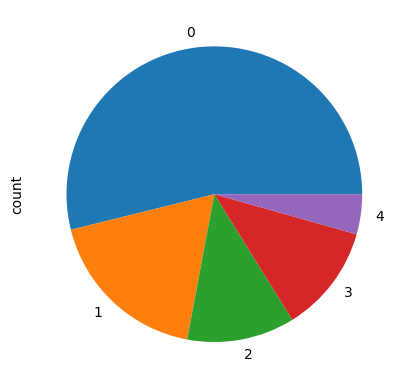

In [14]:
heart_data_nona['num'].value_counts().plot(kind='pie')

## **Zadanie 2.2**

In [15]:
heart_data_nona.describe()

,age,trestbps,chol,thalach,oldpeak,ca,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556,0.676768,0.946128
std,9.049736,17.762806,51.997583,22.941562,1.166123,0.938965,1.234551
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,276.000000,166.000000,1.600000,1.000000,2.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,4.000000


## **Zadanie 2.3**

In [16]:
# moda dla wszystkich cech kategorycznych
heart_data_nona.mode()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,58.0,1,4,120.0,197,0,0,162.0,0,0.0,1,0.0,3.0,0.0
1,NaN,NaN,NaN,NaN,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
heart_data_nona.dtypes[heart_data_nona.dtypes == 'category'].index.tolist()

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [18]:
heart_data_nona.loc[:, heart_data_nona.dtypes[heart_data_nona.dtypes == 'category'].index.tolist()].mode()

,sex,cp,fbs,restecg,exang,slope,thal
0,1,4,0,0,0,1,3.0


## **Zadanie 2.4**

In [19]:
corr_data = heart_data_nona.corr(method ='pearson', numeric_only=True)
corr_data

,age,trestbps,chol,thalach,oldpeak,ca,num
age,1.000000,0.290476,0.202644,-0.394563,0.197123,0.362210,0.222156
trestbps,0.290476,1.000000,0.131536,-0.049108,0.191243,0.097954,0.159620
chol,0.202644,0.131536,1.000000,-0.000075,0.038596,0.115945,0.066448
thalach,-0.394563,-0.049108,-0.000075,1.000000,-0.347640,-0.268727,-0.420639
oldpeak,0.197123,0.191243,0.038596,-0.347640,1.000000,0.294452,0.501461
ca,0.362210,0.097954,0.115945,-0.268727,0.294452,1.000000,0.521178
num,0.222156,0.159620,0.066448,-0.420639,0.501461,0.521178,1.000000


In [20]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

<Axes: >

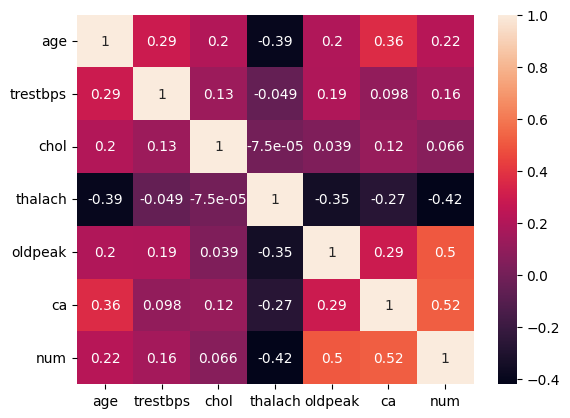

In [ ]:
sns.heatmap(corr_data, annot=True)

## **Zadanie 2.5**

In [ ]:
# sposób
corr_data['age'].abs().nlargest(4)[1:]

thalach     0.394563
ca          0.362210
trestbps    0.290476
Name: age, dtype: float64

In [ ]:
heart_data_nona

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


**Zadanie 3**

Dla zbioru danych Adult: https://archive.ics.uci.edu/dataset/2/adult:

* 3.1 Wykonaj test t dla prób zależnych dla wartości cechy `capital-gain` przyjmując następującą hipotezę zerową: średnia wartość tej cechy dla `race`='White' jest istotnie wyższa niż dla pozostałych wartości cechy `race`. Przyjmij lub odrzuć przyjętą hipotezę.

* 3.2 Wykorzystując test ANOVA sprawdź jak istotna statystycznie jest różnica średniej wartości cechy `capital-gain` dla każdej z wartości `race` z osobna. Wskaż `p-values` dla tego testu. Jak zinterpretować ten wynik?


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

# Pobranie danych
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

# Połączenie cech i etykiety
df = pd.concat([X, y], axis=1)

print(df.head())
print(df.shape)

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [ ]:
white = df[df["race"] == "White"]["capital-gain"]
other = df[df["race"] != "White"]["capital-gain"]

t_stat, p_two = ttest_ind(white, other, equal_var=False)

# test jednostronny
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

t_stat, p_one
#p < 0.05  odrzucamy H0

(np.float64(3.607743754300278), np.float64(0.00015515254828823446))

## 3.2

In [ ]:
groups = [g["capital-gain"].values for _ , g in df.groupby("race")]

f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(np.float64(7.543538179877227), np.float64(4.529130909167219e-06))

In [ ]:
df.groupby("race")["capital-gain"].mean().sort_values(ascending=False)

#p +-= 0.0001
#istnieją istotne różnice między rasami

race
Asian-Pac-Islander    1537.266623
White                 1124.479766
Other                  983.224138
Black                  588.192316
Amer-Indian-Eskimo     538.976596
Name: capital-gain, dtype: float64

**Zadanie 4**

Wykonaj test Chi square dla wartości cechy `capital-income` dla dwóch grup:
* ludzie w wieku < 40 lat
* ludzie w wieku >= 40 lat

Wyświetl wyniki tego testu.

In [6]:
df["age_group"] = np.where(df["age"] < 40, "<40", ">=40")
table = pd.crosstab(df["age_group"], df["income"])
table

income,<=50K,<=50K.,>50K,>50K.
age_group,,,,
<40,15504,7733,2820,1387
>=40,9216,4702,5021,2459


In [ ]:
chi2, p, dof, expected = chi2_contingency(table)
chi2, p, dof
#wiek i dochód są zależne

(np.float64(2545.489163578558), np.float64(0.0), 3)